# SCP Step 5 - Local Run & Analysis

This notebook runs the end-to-end single-cell pipeline in a local NEURON environment.
It assumes the tuned cell files and compiled modfiles already exist in the repo.

What you do here:
1. Pick a cell/tune and load configs from `cells/<CELL>/tunes/<TUNE>/cell_configs/`.
2. Build cell + geometry, generate inputs, and preview synapse placement.
3. Run single/multi trials and save results to `output_data/`.
4. Run quick analysis/plots for sanity checks.

Core logic lives in `modules_local/`. This notebook wires configs to those functions.

Use `5_colab.ipynb` if you need a bootstrapped environment (download + install + compile).


Bio curve helper: `modules_local.bio_curve.load_bio_curve`.


In [1]:
from modules_local.bio_curve import load_bio_curve
# Dev helper: autoreload modules_local and ensure repo on sys.path
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
repo_root = Path('/home/hrbncv/SCP').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport


In [2]:
import os, sys, csv, json, h5py, random, math, pickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

from allensdk.api.queries.biophysical_api import BiophysicalApi
from allensdk.model.biophys_sim.config import Config
from allensdk.model.biophysical.utils import Utils


# from modules_local import download_cell

from modules_local import load_cell
from modules_local import geometry
from modules_local import inputs
from modules_local import synapses

from modules_local import run_sim
from modules_local import plotting


--No graphics will be displayed.


In [3]:
# Select the cell/tune and move into the tune directory (legacy behavior)
cell_name = 'SST'  # SST, SST_0, PV, PN
tunes_dir = 'tunes'
model_dir = 'seg_tuned'

tune_dir = Path('cells') / cell_name / tunes_dir / model_dir
if not tune_dir.is_dir():
    raise FileNotFoundError(f'Expected tune dir not found: {tune_dir}')
os.chdir(tune_dir)
print('CWD:', Path.cwd())

# Defaults from cell_configs (fallback if sim_config.json is missing)
cell_cfg_defaults = {}
cell_cfg_path = Path('cell_configs') / 'cell_config.json'
if cell_cfg_path.is_file():
    cell_cfg_defaults = json.loads(cell_cfg_path.read_text())

specimen_id = cell_cfg_defaults.get('specimen_id')
model_type = cell_cfg_defaults.get('model_type', 'perisomatic')
soma_diam_multiplier = float((cell_cfg_defaults.get('tuning') or {}).get('soma_diam_multiplier', 1.0))

# Override from sim_config.json when available (cell_configs preferred)
sim_cfg_path = Path('cell_configs') / 'sim_config.json'
if not sim_cfg_path.is_file():
    sim_cfg_path = Path('sim_config.json')
sim_cfg_preview = None
if sim_cfg_path.is_file():
    sim_cfg_preview = json.loads(sim_cfg_path.read_text())
    specimen_id = sim_cfg_preview.get('specimen_id', specimen_id)
    model_type = sim_cfg_preview.get('model_type', model_type)
    soma_diam_multiplier = float(sim_cfg_preview.get('soma_diam_multiplier', soma_diam_multiplier))


CWD: /home/hrbncv/SCP/cells/SST/tunes/seg_tuned


In [4]:
from neuron import h
h.load_file("stdrun.hoc")  # Required to use h.run()
h.nrn_load_dll("modfiles/x86_64/.libs/libnrnmech.so")


1.0

In [5]:
# Load in-vivo firing-rate curve once (PN)
from modules_local import bio_curve

in_vivo_curve_raw = bio_curve.load_bio_curve(
    "/home/hrbncv/SCP/external_data/pyrFiringRateAvg.csv",
    time_col="Time",
    rate_col="AvgFiringRate",
    t_min=0.0,
    delay_ms=0.0,
    time_unit="s",
)

# Default (unshifted); will be aligned after groups_cfg is available
in_vivo_curve = in_vivo_curve_raw


# Step 5.2 - Build Cell

This section constructs a single NEURON cell, ready for simulation, in four substeps:

5.2.1 **Load Cell**  
: Build the NEURON cell object from the tuned model files.

5.2.2 **Define Geometry**  
: Create a standardized geometry view with named segment groups (e.g. soma, proximal dendrites).

5.2.3 **Generate Inputs**  
: Generate spike trains for each synapse group (homogeneous, inhomogeneous, fixed, etc.), independent of morphology.

5.2.4 **Preview Synapses**  
: Preview synapse placement and weights without attaching NEURON objects.


## 5.2.1 Load Cell

In this step, we construct the NEURON cell object from the tuned model files.  
The notebook will pass a configuration dictionary (`cell_config`) to a single function `load_cell(...)` in `modules_local`, which internally handles all model-specific details (e.g., Allen vs custom, manifest paths, soma tuning).  
The result is a `cell` handle that owns the NEURON sections and is ready for further processing.


In [6]:
# Minimal cell configuration for the current tuned Allen model
cell_config_path = Path("cell_configs") / "cell_config.json"
if cell_config_path.is_file():
    cell_config = json.loads(cell_config_path.read_text())
else:
    cell_config = {}

cell_config.setdefault("cell_name", cell_name)
paths = cell_config.setdefault("paths", {})
paths.setdefault("manifest", "manifest.json")

tuning = cell_config.setdefault("tuning", {})
if "soma_diam_multiplier" not in tuning:
    tuning["soma_diam_multiplier"] = soma_diam_multiplier

if 'sim_cfg_preview' in globals() and sim_cfg_preview:
    if "soma_diam_multiplier" in sim_cfg_preview:
        tuning["soma_diam_multiplier"] = sim_cfg_preview["soma_diam_multiplier"]
    if "specimen_id" in sim_cfg_preview:
        cell_config["specimen_id"] = sim_cfg_preview["specimen_id"]
    if "model_type" in sim_cfg_preview:
        cell_config["model_type"] = sim_cfg_preview["model_type"]


In [7]:
from modules_local.load_cell import load_cell

cell = load_cell(cell_config)

print("Loaded cell:", cell)


Loaded Allen cell for 'SST' from manifest.json, soma_diam_multiplier=8.0, Vinit=-85.0
Loaded cell: LoadedCell(label='SST')


## 5.2.1b Current Injection Test (optional)

Quick somatic IClamp to check base cell behavior without synapses/inputs.


In [8]:
# IClamp mode (cell-only), controlled by cell_configs/sim_config.json
iclamp_cfg = (sim_cfg_preview or {}).get("iclamp", {}) if "sim_cfg_preview" in globals() else {}
run_iclamp_mode = bool(iclamp_cfg.get("enabled", False))
if run_iclamp_mode:
    print("IClamp mode enabled (cell_configs/sim_config.json -> iclamp.enabled = true)")


## 5.2.2 Define Geometry

Here we create a standardized geometry view of the cell that is independent of how the cell was originally built.  
Given the `cell` and a configuration dictionary (`geom_config`), the function `define_geometry(...)` in `modules_local` will group segments into named sets (e.g., `soma`, `prox_dend`, `dist_dend`, `all_dend`) and compute path distances from a defined origin.  
The result is a `geom` structure that maps group names to lists of target locations `(sec, x, dist_um)` for synapse placement.


In [9]:
# Geometry configuration (loaded from tune-specific config)
geom_config_path = Path("cell_configs") / "geometry.json"
if geom_config_path.is_file():
    geom_config = json.loads(geom_config_path.read_text())
else:
    geom_config = {}

geom_config.setdefault("label", f"{cell_name}_default_geometry")


'SST_default_geometry'

In [10]:
from modules_local.geometry import define_geometry

geom = define_geometry(cell, geom_config)

print("Geometry label:", geom.get("label", "<unnamed>"))
print("Geometry groups:", list(geom.get("groups", {}).keys()))

Geometry defined for 'SST': 1 soma segs, 54 proximal dend segs, 52 distal dend segs, 115 total dend segs.
Geometry label: SST_default_geometry
Geometry groups: ['soma', 'proximal', 'distal', 'all_dend']


## 5.2.3 Generate Inputs

In this step we generate spike trains for each synapse group, completely separate from the cell morphology.  
The function `generate_inputs(...)` in `modules_local` will use `input_config`, `sim_params`, and `syn_params` to create spike-time arrays from various source types (e.g., fixed trains, homogeneous Poisson, inhomogeneous bio traces, baseline+bio windows).  
The output `inputs` is a pure Python/NumPy structure (no NEURON objects) organized per population and synapse group.


In [11]:
from pathlib import Path
from modules_local import inputs

# working dir = tune folder
sim_cfg_preview, groups_cfg_preview = inputs.check_inputs()
print("Simulation config preview:", sim_cfg_preview)
print("Groups config preview:", groups_cfg_preview)

=== check_inputs: synapse config summary ===
Sim cfg: {'tstart': 0.0, 'tstop': 1200.0, 'dt': 0.025, 'bins': 5.0, 'jitter': 100.0, 'stim_start_ms': 500.0, 'stim_duration_ms': 500.0, 'n_trials': 1, 'n_traces_to_save': 1, 'n_inputs_to_save': 1, 'load': None, 'save': 'slurm_test', 'append': None, 'input_stats_bin_ms': 5.0, 'avg_rate_curve_smooth_ms': 25.0, 'avg_rate_curve_smooth_mode': 'causal', 'plots_win_size': 25.0, 'plots_input_smooth_ms': 25.0, 'plots_profile': 'off', 'randomness_mode': 'random', 'random_seed': None, 'param_study': {'input_type': None, 'param_type': None, 'param_vals': [], 'n_trials': None}, 'iclamp': {'enabled': False, 'amp_nA': 0.2, 'delay_ms': 200.0, 'dur_ms': 800.0, 'tstop_ms': None, 'dt_ms': None, 'record_currents': False}, 'snapshot': {'enabled': False, 'n_trials': 1, 'save_all_inputs': True, 'save_all_traces': True, 'save_syn_records_by_trial': True}, 'stim_stop_ms': None, 'seed': None, 'trial_randomness': 'synapses', 'load_enabled': False, 'save_output': False

In [12]:
# === Step 2.3: Generate Inputs ===
if run_iclamp_mode:
    sim_cfg = inputs._normalize_sim_config(sim_cfg_preview)
    inputs._inject_path_metadata(sim_cfg, sim_cfg_path.parent)
    groups_cfg = {}
    inputs_by_group = {}
    print("IClamp mode: skipping inputs generation.")
else:
    sim_cfg, groups_cfg, inputs_by_group = inputs.generate_inputs(geometry=geom)

    # print(inputs_by_group)
    print("sim_cfg:", sim_cfg)
    print("save:", sim_cfg.get("save"), "append:", sim_cfg.get("append"))
    print("Generated input groups:")
    for name, gi in inputs_by_group.items():
        print(f"  - {name:15s} mode={gi.mode!r:18}  n_trains={len(gi.spike_trains)}")
        
    print("seed:", sim_cfg.get("seed"))
    print("rand_seed:", sim_cfg.get("random_seed"))
    print("rand_global_seed:", sim_cfg.get("randomness", {}).get("global", {}).get("seed"))


sim_cfg: {'tstart': 0.0, 'tstop': 1200.0, 'dt': 0.025, 'bins': 5.0, 'jitter': 100.0, 'stim_start_ms': 500.0, 'stim_duration_ms': 500.0, 'n_trials': 1, 'n_traces_to_save': 1, 'n_inputs_to_save': 1, 'load': None, 'save': 'slurm_test', 'append': None, 'input_stats_bin_ms': 5.0, 'avg_rate_curve_smooth_ms': 25.0, 'avg_rate_curve_smooth_mode': 'causal', 'plots_win_size': 25.0, 'plots_input_smooth_ms': 25.0, 'plots_profile': 'off', 'randomness_mode': 'random', 'random_seed': None, 'param_study': {'input_type': None, 'param_type': None, 'param_vals': [], 'n_trials': None}, 'iclamp': {'enabled': False, 'amp_nA': 0.2, 'delay_ms': 200.0, 'dur_ms': 800.0, 'tstop_ms': None, 'dt_ms': None, 'record_currents': False}, 'snapshot': {'enabled': False, 'n_trials': 1, 'save_all_inputs': True, 'save_all_traces': True, 'save_syn_records_by_trial': True}, 'stim_stop_ms': None, 'seed': None, 'trial_randomness': 'synapses', 'load_enabled': False, 'save_output': False, 'output': 'slurm_test', 'output_format': 'p

## 5.2.4 Preview Synapses

Preview synapse placement and weights without attaching NEURON objects.  
Use `synapses.preview_synapses(...)` to generate a `syn_state` record for plotting.  
Actual synapse attachment happens inside Step 5.3 (run_sim) so single and multi runs stay consistent.


In [13]:
# === Step 2.4: Preview synapse placement (no NEURON objects) ===
if run_iclamp_mode:
    print("IClamp mode: skipping synapse preview.")
else:
    from modules_local import synapses, randomness

    # 2.3 outputs: sim_cfg, groups_cfg, inputs_by_group
    # 2.1/2.2: cell, geom

    preview_synapses = True
    if preview_synapses:
        rm_preview = randomness.RandomnessManager(sim_cfg)
        trial_rng = rm_preview.trial(0)
        syn_state = synapses.preview_synapses(
            cell=cell,
            geom=geom,
            sim_cfg=sim_cfg,
            groups_cfg=groups_cfg,
            inputs_by_group=inputs_by_group,
            trial_rng=trial_rng,
        )

        print("Step 2.4: synapse preview complete (no NEURON objects attached).")
        print("Synapse groups:", list(syn_state.get("records", {}).keys()))
        for gname, records in syn_state.get("records", {}).items():
            print(f"  {gname}: {len(records)} synapse records")
    else:
        print("Synapse preview disabled.")


Step 2.4: synapse preview complete (no NEURON objects attached).
Synapse groups: ['pn_exc', 'vip_inh_bio', 'bg_exc', 'bg_inh', 'bg_exc_del']
  pn_exc: 50 synapse records
  vip_inh_bio: 12 synapse records
  bg_exc: 3382 synapse records
  bg_inh: 796 synapse records
  bg_exc_del: 100 synapse records


In [14]:
# --- Debug synapse records (safe) ---
if "syn_state" not in globals() or syn_state is None:
    print("syn_state not available (preview not run).")
else:
    for g, recs in syn_state.get("records", {}).items():
        if not recs:
            continue
        print(g, "n_syn:", len(recs), "example weight:", recs[0].weight, "first spikes:", recs[0].spike_times[:5])
    if "groups_cfg" in globals():
        print("Groups configuration:", groups_cfg)


pn_exc n_syn: 50 example weight: 0.5314504770080191 first spikes: [624.7868840497908, 829.3659829609031, 1077.4113187991543]
vip_inh_bio n_syn: 12 example weight: 0.9593153199904595 first spikes: [717.2186232965964, 739.9943301799609, 782.0068759417541, 789.370036546367, 893.3024313367637]
bg_exc n_syn: 3382 example weight: 0.2206089774359065 first spikes: []
bg_inh n_syn: 796 example weight: 0.5215207604461556 first spikes: [602.6367035350463]
bg_exc_del n_syn: 100 example weight: 0.3584321206665824 first spikes: []
Groups configuration: {'pn_exc': {'state': True, 'mode': 'inhomogeneous_poisson', 'color': '#1f77b4', 'source': {'freq': None, 'baseline': 2.3, 'path': 'external_data/pyrFiringRateAvg.csv', 'bin_ms': 5, 'kind': None, 'time_col': None, 'rate_col': None, 'ref': None, 'key': None}, 'timing': {'onset_ms': None, 'stim_tstart_ms': 500.0, 'duration_ms': None, 'input_stim_tstart_ms': 0.0, 'input_duration_ms': None}, 'syns': {'type': 'AMPA_NMDA_STP', 'N_syn': 50, 'segs': 'all', 'di

# Step 5.3 - Run Simulations

run_sim modes:

5.3.1 **Single Sim** (run_single)

5.3.2 **Multi Sim** (run_multi)

5.3.3 **Parametric Sweep** (run_param)


In [15]:
# === Step 3.1: Run simulation (IClamp or normal) ===
from modules_local import run_sim

if run_iclamp_mode:
    print("Running IClamp test (no synapses/inputs).")
    results = run_sim.run_iclamp_test(cell, sim_cfg, iclamp_cfg=iclamp_cfg)
else:
    # sim_cfg comes from Step 2.3 and already has dt, tstart, tstop, seed, etc.
    results = run_sim.run_sim(
        cell,
        geom,
        sim_cfg,
        groups_cfg,
        inputs_by_group,
        meta_overrides={"cell_config": cell_config, "geometry_config": geom_config},
    )
    run_sim.summarize_results(results)
# single-trial case (works for IClamp too)
T = results["traces"]["T"]
V = results["traces"]["V"]
spikes = results.get("spikes")


mode=single, n_traces_to_save=1
  single: len(T)=48001, len(V)=48001, n_spikes=8


### Step 5.3.4 - Save Results (auto)

Saves using the same workflow as the CLI/slurm pipeline.


In [16]:
# --- Manual save (optional; auto-save already happens inside run_sim.run_sim) ---
do_manual_save = False
if do_manual_save:
    from datetime import datetime
    from pathlib import Path
    
    save_output = sim_cfg.get("save_output", True)
    if save_output is None:
        save_output = True
    save_output = bool(save_output)
    
    if save_output:
        if not sim_cfg.get("output"):
            sim_cfg["output"] = datetime.now().strftime("nb_%Y%m%d_%H%M%S")
        out_dir = Path("output_data")
        saved_path = run_sim.save_results(results, base_dir=out_dir)
        if saved_path is None:
            print("Results not saved (sim_cfg['output'] was empty).")
        else:
            print(f"Results saved to {saved_path}")
    else:
        print("Auto-save disabled (sim_cfg['save_output']=False).")
else:
    print("Skipping manual save (auto-save handled by run_sim.run_sim).")


Skipping manual save (auto-save handled by run_sim.run_sim).


Trials: 1
Spike count per trial: mean=8.00, std=0.00, min=8, max=8
Counts (first 10): [8.0]
Avg rate per trial (Hz): mean=6.67, std=0.00


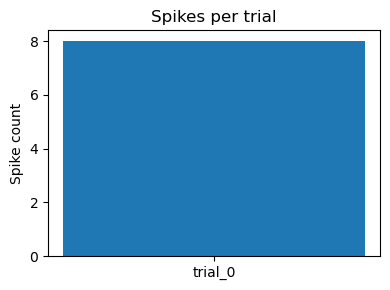

In [17]:
# --- Quick stats: spikes per trial ---
if run_iclamp_mode:
    print("Skipping spike stats (IClamp mode).")
else:
    from modules_local.analysis import summarize_spike_trials

    plot_trial_stats = True
    trial_stats = summarize_spike_trials(results, plot=plot_trial_stats)
    # trial_stats


# Step 5.4 - Analyze Results

## Analyze Results:

5.4.1 **Cell & Synapse Generation**  

5.4.2 **Input Generation**

5.4.3 **Simulation Analysis**  

## Extra Modules (optional):
5.4.4 **Loaded Sim Data**    

5.4.5 **Multi Loaded Sim Data**


### Step 5.4.1 Cell & Synapse Generation


In [18]:
if run_iclamp_mode:
    print("Skipping Step 4.1 (IClamp mode).")
else:
    # === Step 4.1: Analyze Cell & Synapse Generation ===
    # Align in-vivo curve to PN stimulation timing (if available)
    stim_group = "pn_exc"
    try:
        timing = groups_cfg.get(stim_group, {}).get("timing", {})
        stim_tstart = timing.get("stim_tstart_ms")
        input_stim = timing.get("input_stim_tstart_ms")
        if stim_tstart is None:
            stim_tstart = sim_cfg.get("stim_start_ms")
        if stim_tstart is not None:
            shift_ms = float(stim_tstart)
            if input_stim is not None:
                shift_ms = float(stim_tstart) - float(input_stim)
            t_s, rate = in_vivo_curve_raw
            in_vivo_curve = (t_s + shift_ms / 1000.0, rate)
    except Exception:
        pass


Detected 8 spikes (total avg: 7.2727272727272725) at times (ms): [178.775 309.15  654.3   741.75  786.175 886.45  935.975 994.95 ]


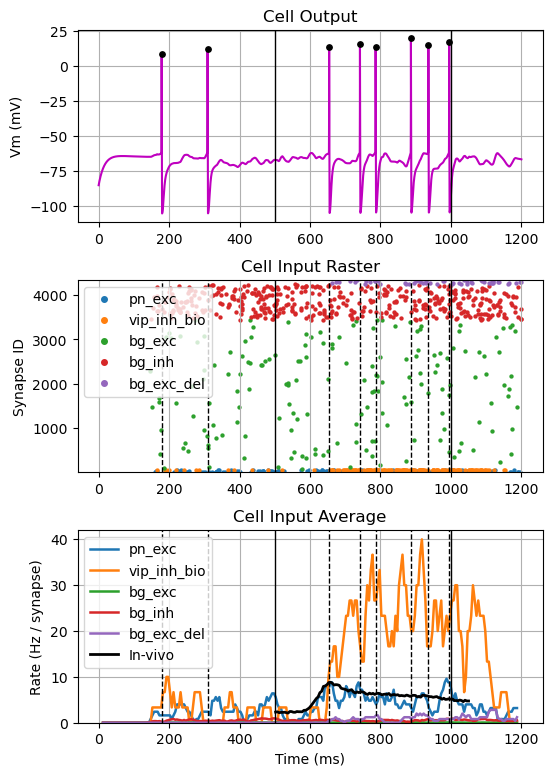

In [19]:
# === Step 4.3: Analyze Single Sim ===
from modules_local import plotting

if run_iclamp_mode:
    plt.figure(figsize=(6, 4))
    plt.plot(T, V, lw=1.5)
    plt.xlabel("Time (ms)")
    plt.ylabel("Vm (mV)")
    plt.title("IClamp test (soma)")
    plt.tight_layout()
else:
    plotting.plot_results(
        results,
        syn_records=results.get("syn_records"),
        in_vivo_curve=in_vivo_curve,
        win_size=25,
        raster_style='dot',
        plot_window=(None, None),  # or (None, None) to auto
    )


# Extra Modules (optional)


In [20]:
sys.exit("Stopping notebook here")

SystemExit: Stopping notebook here

/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# --- Example: save a labeled single run --- 
do_save_example = False
if do_save_example:
    from modules_local import run_sim

    results = run_sim.run_sim(cell, geom, sim_cfg, groups_cfg, inputs_by_group)
    # tweak anything you like (color, meta, etc.)
    results["sim_cfg"]["color"] = "m"
    results["meta"]["note"] = "batch 1, bg_exc only"

    run_sim.save_results_with_name(results, "sst2_seg_tuned_bgexc_batch1")


In [ ]:
from pathlib import Path
from modules_local import run_sim, plotting

# load directly from disk; ignores current sim_cfg
do_load_results = False
if do_load_results:
    output_stem = "tune1"
    results_name = f"SST_seg_tuned_{output_stem}.pkl"
    base = Path("output_data")
    run_dir = base / output_stem
    results_file = run_dir / results_name
    legacy_file = base / results_name

    if run_dir.is_dir():
        results_path = run_dir
    elif results_file.is_file():
        results_path = results_file
    elif legacy_file.is_file():
        results_path = legacy_file
    else:
        raise FileNotFoundError(
            f"Set results_path to an existing run folder or file (got {run_dir})"
        )

    results = run_sim.load_results(results_path)

    # optional: tweak plot-only fields such as color
    results["sim_cfg"]["color"] = "m"

    # optional: build in_vivo_curve from current groups_cfg/sim_cfg (if you have them)
    # in_vivo_curve = (delayed_PFR_t, PFR_firing_rate_shortened)

    plotting.plot_results(results, in_vivo_curve=in_vivo_curve)
